# Financial Risk & Loan Analytics

## 1. Import Libraries

In [ ]:
# ==========================
# Import necessary libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

## 2. Load Dataset

In [ ]:
# Load the dataset

df = pd.read_csv("../data/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Dataset Overview

In [3]:
# Shape of Dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 32581
Columns : 12


In [4]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [5]:
# Statistical Summary

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


## 4. Data Quality Assessment

In [6]:
# Missing Values

missing = df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing/len(df))*100
})

missing

,Missing Values,Percentage
person_age,0,0.000000
person_income,0,0.000000
person_home_ownership,0,0.000000
person_emp_length,895,2.747000
loan_intent,0,0.000000
loan_grade,0,0.000000
loan_amnt,0,0.000000
loan_int_rate,3116,9.563856
loan_status,0,0.000000
loan_percent_income,0,0.000000


In [17]:
# Check for duplicate records in the dataset

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 165


## 5. Exploratory Data Analysis (EDA)

loan_status
0    25473
1     7108
Name: count, dtype: int64


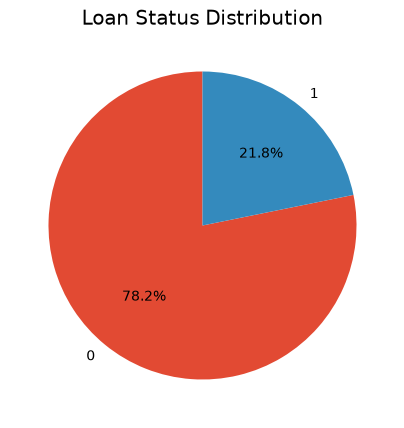

In [18]:
# Visualize the distribution of loan default status

plt.figure(figsize=(5,5))

loan_status = df["loan_status"].value_counts()

print(loan_status)

plt.pie(
    loan_status,
    labels=loan_status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Status Distribution")
plt.show()

In [19]:
# Display all numerical features in the dataset

df.select_dtypes(include=np.number).columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='str')

In [20]:
# Display all categorical features in the dataset

df.select_dtypes(include="object").columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

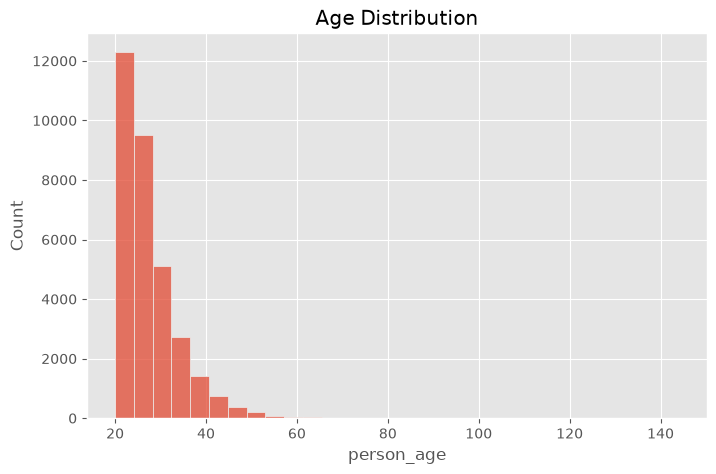

In [ ]:
# Plot age distribution

plt.figure(figsize=(8,5))

sns.histplot(df["person_age"], bins=30)

plt.title("Age Distribution")
plt.show()

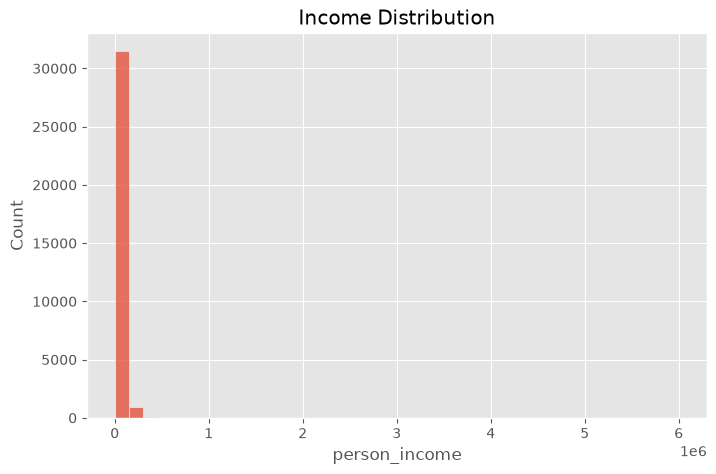

In [21]:
# Plot income distribution

plt.figure(figsize=(8,5))

sns.histplot(df["person_income"], bins=40)

plt.title("Income Distribution")
plt.show()

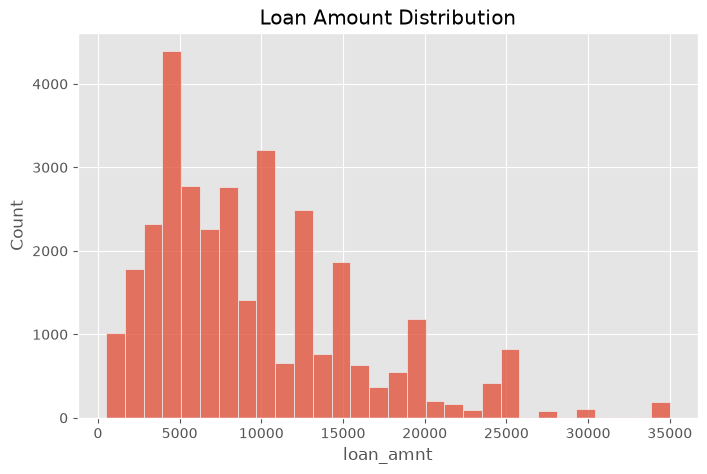

In [22]:
# Plot loan amount distribution

plt.figure(figsize=(8,5))

sns.histplot(df["loan_amnt"], bins=30)

plt.title("Loan Amount Distribution")
plt.show()

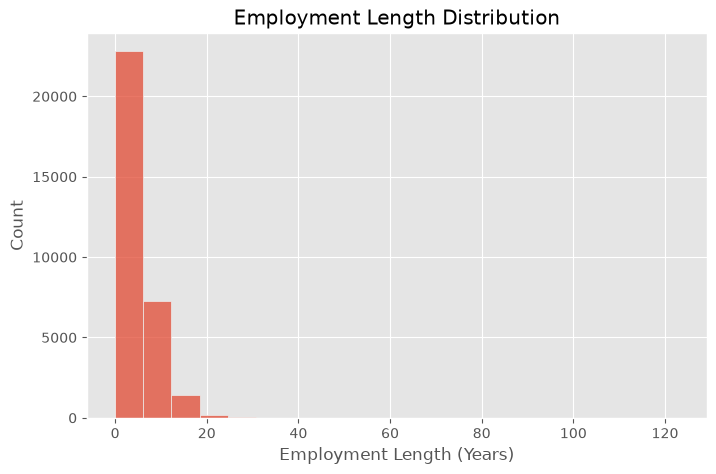

In [23]:
# Plot the distribution of employment length

plt.figure(figsize=(8,5))

sns.histplot(df["person_emp_length"], bins=20)

plt.title("Employment Length Distribution")
plt.xlabel("Employment Length (Years)")
plt.ylabel("Count")

plt.show()

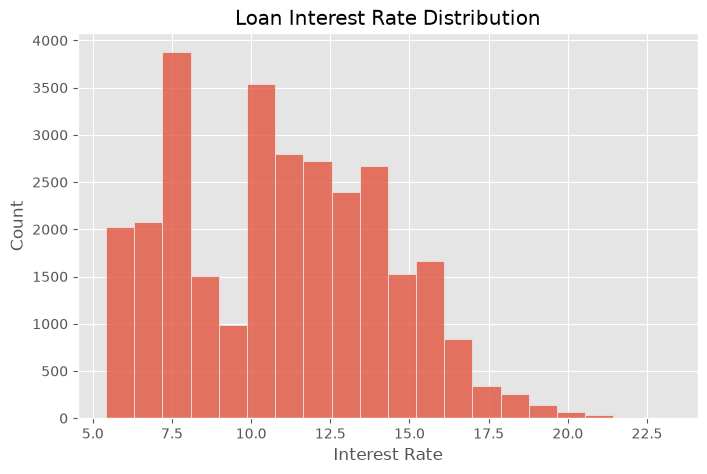

In [24]:
# Plot the distribution of loan interest rates

plt.figure(figsize=(8,5))

sns.histplot(df["loan_int_rate"], bins=20)

plt.title("Loan Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Count")

plt.show()

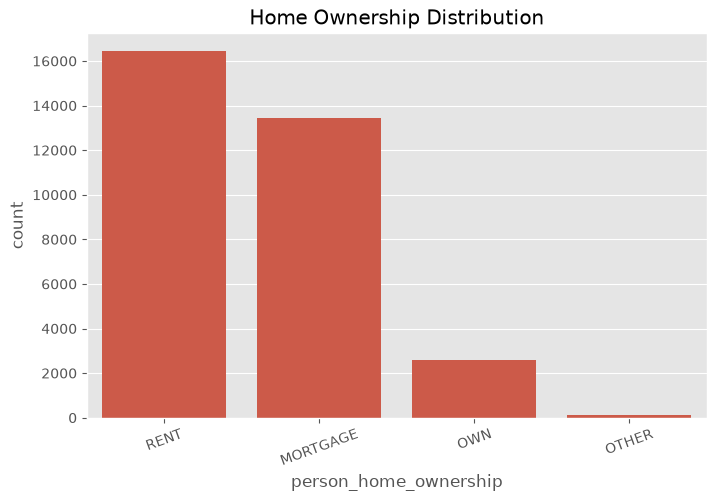

In [25]:
# Plot the distribution of home ownership categories

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="person_home_ownership",
    order=df["person_home_ownership"].value_counts().index
)

plt.title("Home Ownership Distribution")
plt.xticks(rotation=20)

plt.show()

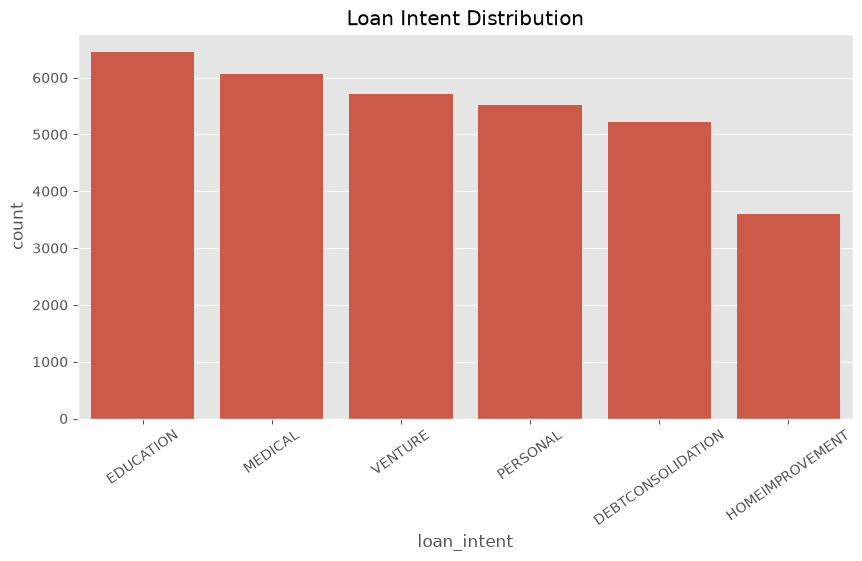

In [26]:
# Plot the distribution of loan purposes

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="loan_intent",
    order=df["loan_intent"].value_counts().index
)

plt.title("Loan Intent Distribution")
plt.xticks(rotation=35)

plt.show()

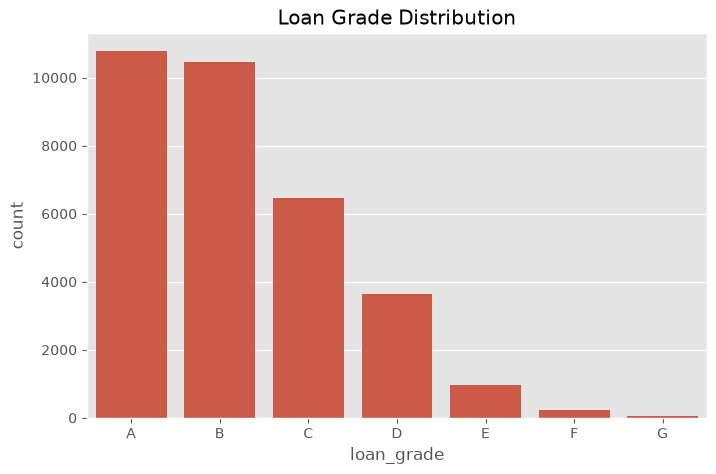

In [27]:
# Plot the distribution of loan grades

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="loan_grade",
    order=sorted(df["loan_grade"].unique())
)

plt.title("Loan Grade Distribution")

plt.show()

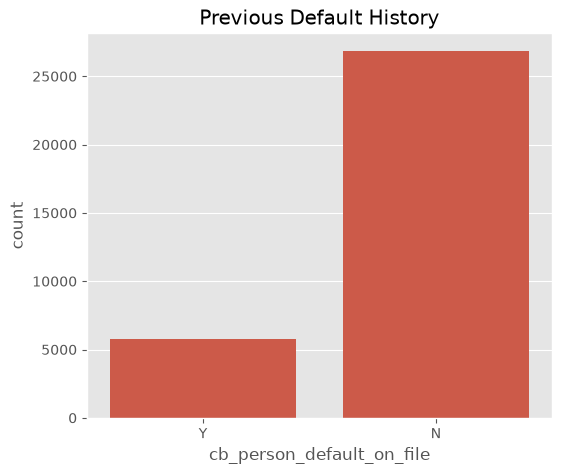

In [28]:
# Plot previous default history of applicants

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="cb_person_default_on_file"
)

plt.title("Previous Default History")

plt.show()

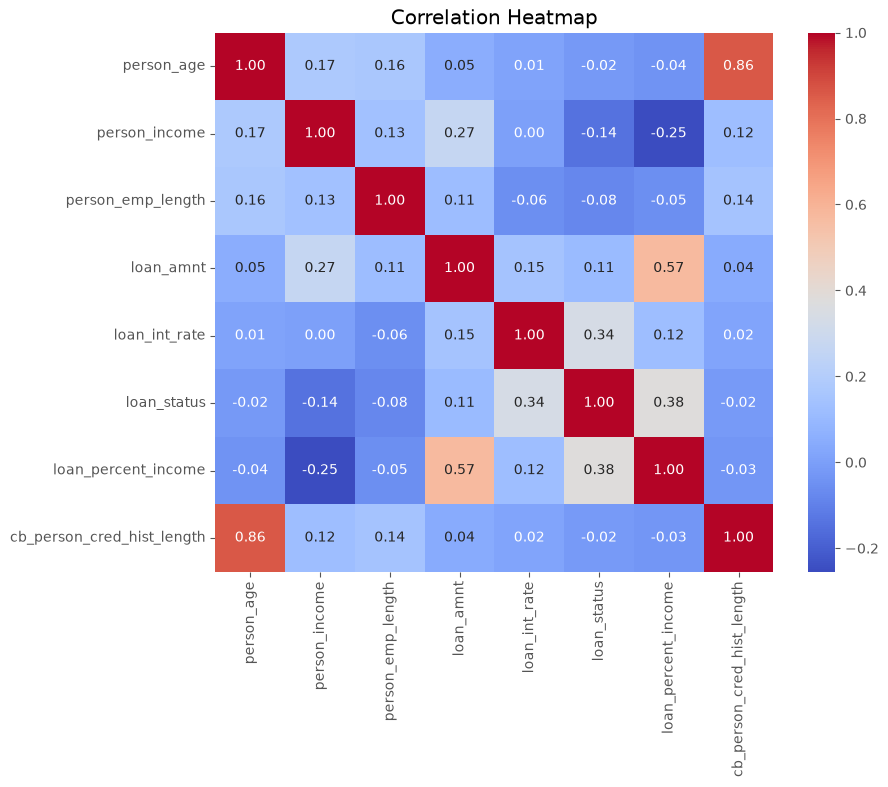

In [29]:
# Display the correlation matrix for numerical features

plt.figure(figsize=(9,7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

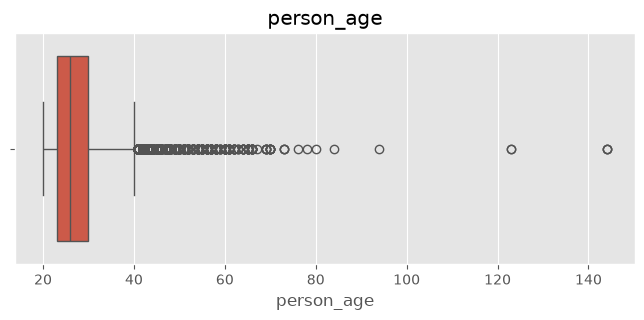

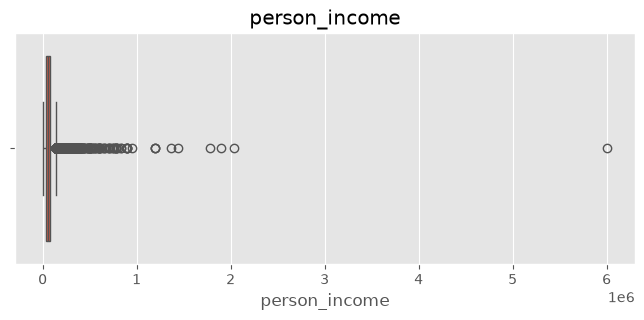

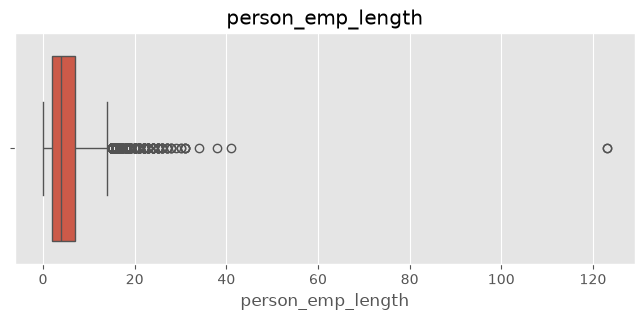

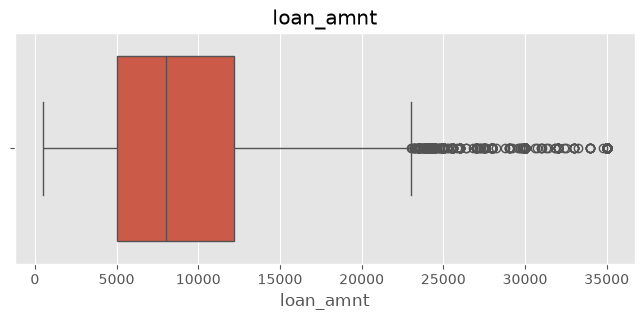

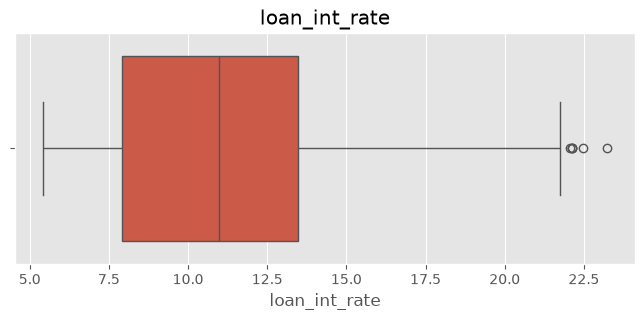

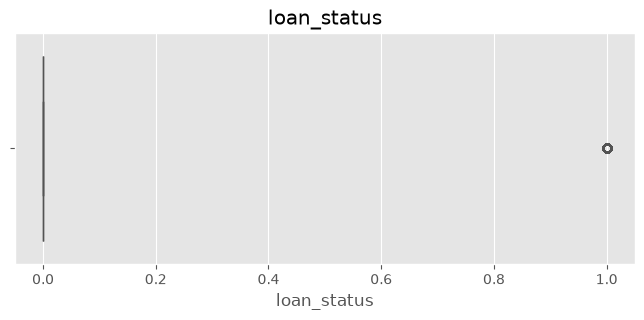

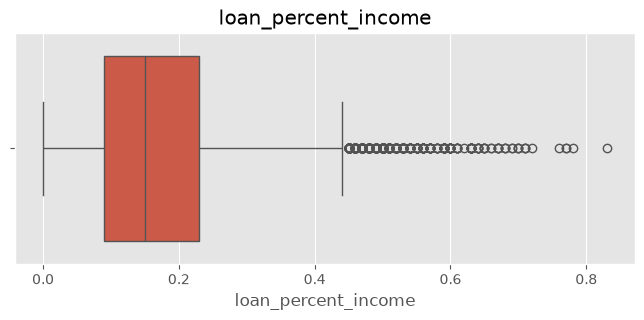

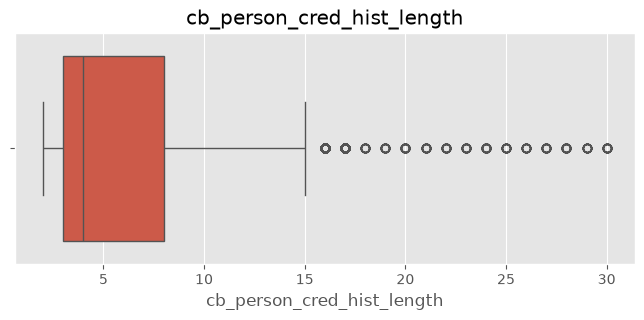

In [30]:
# Plot boxplots to detect outliers in numerical features

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

## 6. Data Cleaning

In [31]:
# Remove duplicate records from the dataset

print("Rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows before removing duplicates: 32581
Rows after removing duplicates: 32416


In [32]:
# Display missing values after removing duplicates

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing / len(df)) * 100, 2)
})

missing_df

,Missing Values,Percentage
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
person_emp_length,887,2.74
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_int_rate,3095,9.55
loan_status,0,0.00
loan_percent_income,0,0.00


In [37]:
# Fill missing values in numerical columns using the median

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

In [38]:
# Verify that all missing values have been handled

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [39]:
# Display the updated dataset dimensions

print(df.shape)

(32416, 12)


In [40]:
# Display data types after preprocessing

df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

In [41]:
# Display the Interquartile Range (IQR) for numerical features

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

person_age: 1491 outliers
person_income: 1478 outliers
person_emp_length: 852 outliers
loan_amnt: 1679 outliers
loan_int_rate: 70 outliers
loan_status: 7089 outliers
loan_percent_income: 650 outliers
cb_person_cred_hist_length: 1139 outliers


In [42]:
# Cap outliers using the IQR method

numerical_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

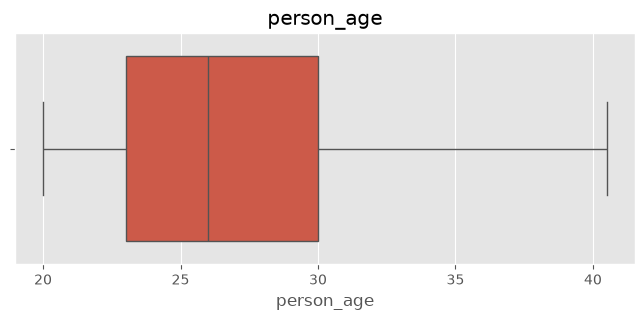

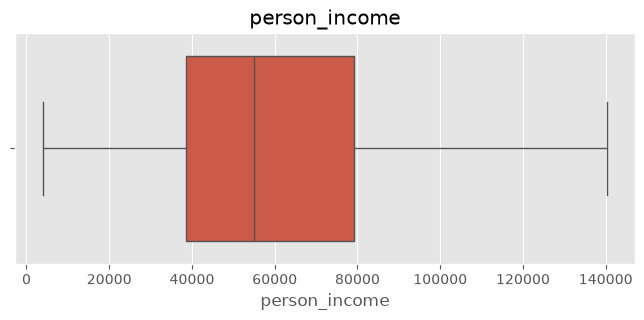

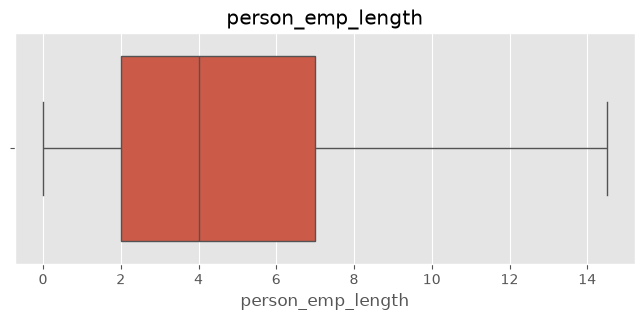

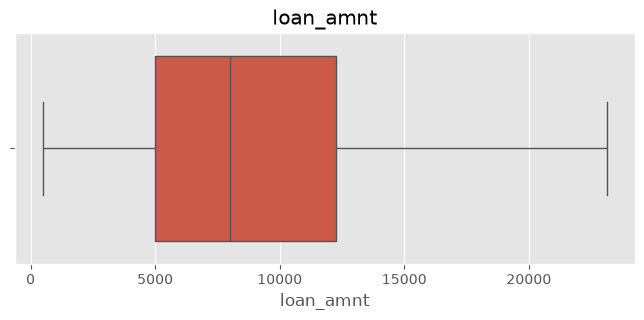

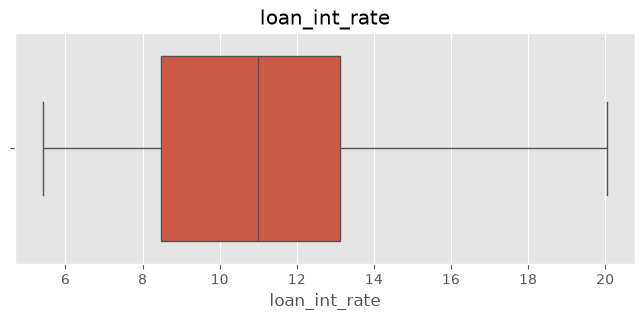

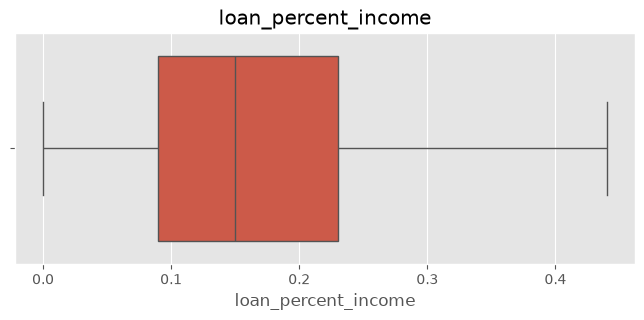

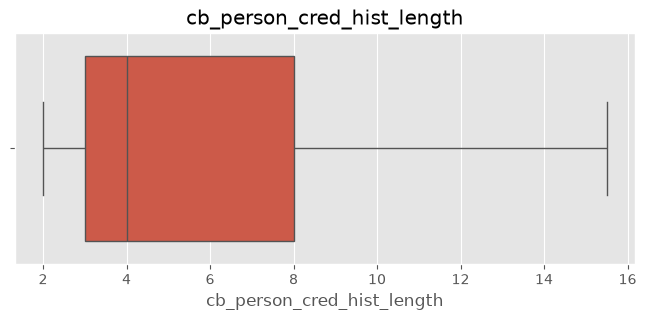

In [43]:
# Verify outliers after capping

for col in numerical_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [44]:
# Save the cleaned dataset

df.to_csv("../data/cleaned_credit_risk_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 7. Data Preprocessing

In [45]:
# Import libraries required for machine learning

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [46]:
# Encode categorical features using Label Encoding

label_encoder = LabelEncoder()

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000,3,14.5,4,3,23125,16.02,1,0.44,1,3.0
1,21.0,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2.0
2,25.0,9600,0,1.0,3,2,5500,12.87,1,0.44,0,3.0
3,23.0,65500,3,4.0,3,2,23125,15.23,1,0.44,0,2.0
4,24.0,54400,3,8.0,3,2,23125,14.27,1,0.44,1,4.0


In [47]:
# Verify encoded categorical variables

df[categorical_cols].head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,3,4,3,1
1,2,1,1,0
2,0,3,2,0
3,3,3,2,0
4,3,3,2,1


In [48]:
# Separate input features and target variable

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (32416, 11)
Target Shape : (32416,)


In [49]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (25932, 11)
Testing Set : (6484, 11)


In [50]:
# Scale numerical features using StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## 8. Model Building

In [51]:
# Import machine learning algorithms

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [52]:
# Train the Logistic Regression model

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [53]:
# Train the Decision Tree model

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [54]:
# Train the Random Forest model

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 9. Model Evaluation

In [63]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [56]:
# Evaluate Logistic Regression

lr_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

Accuracy : 0.8471622455274522

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      5066
           1       0.73      0.48      0.58      1418

    accuracy                           0.85      6484
   macro avg       0.80      0.72      0.74      6484
weighted avg       0.84      0.85      0.84      6484



In [57]:
# Evaluate Decision Tree

dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

Accuracy : 0.8892658852560148

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5066
           1       0.74      0.76      0.75      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.84      0.84      6484
weighted avg       0.89      0.89      0.89      6484



In [58]:
# Evaluate Random Forest

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Accuracy : 0.932140653917335

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.71      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.95      0.85      0.89      6484
weighted avg       0.93      0.93      0.93      6484



In [59]:
# Compare model accuracies

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.932141
1,Decision Tree,0.889266
0,Logistic Regression,0.847162


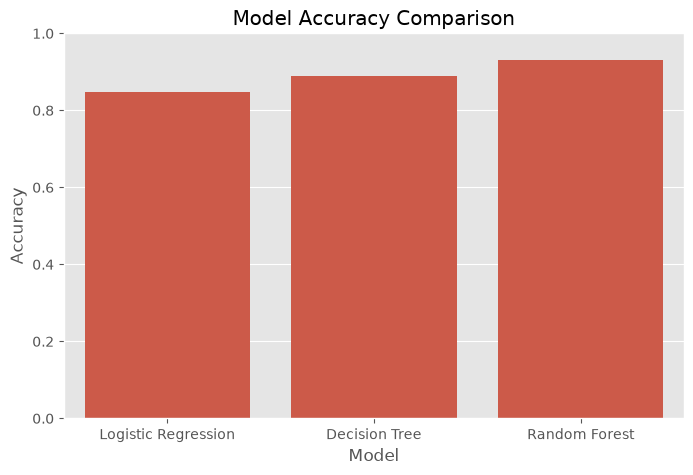

In [60]:
# Plot model accuracy comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()

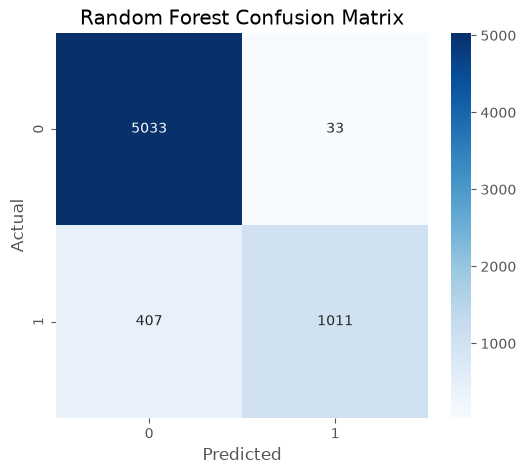

In [61]:
# Display confusion matrix for the Random Forest model

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

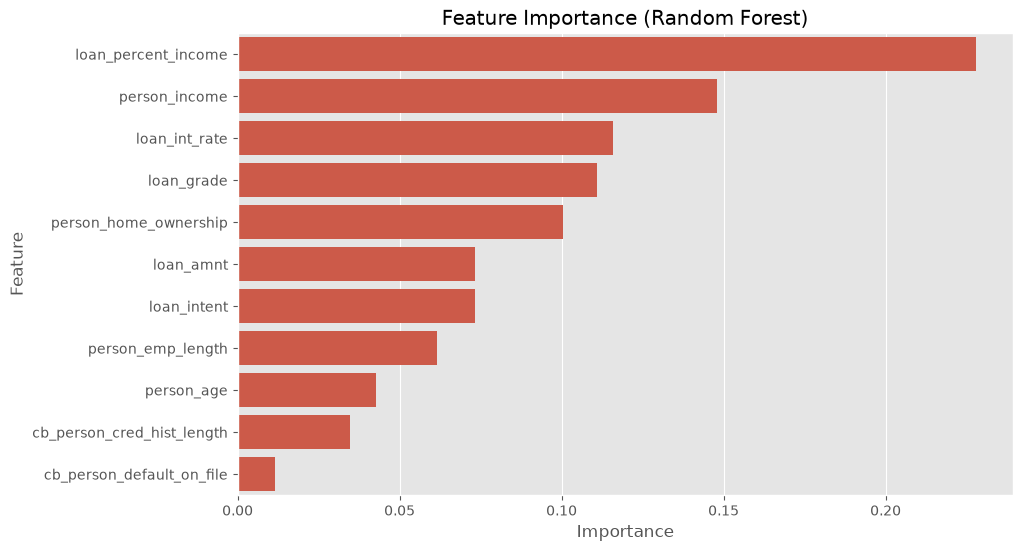

In [62]:
# Display feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")

plt.show()

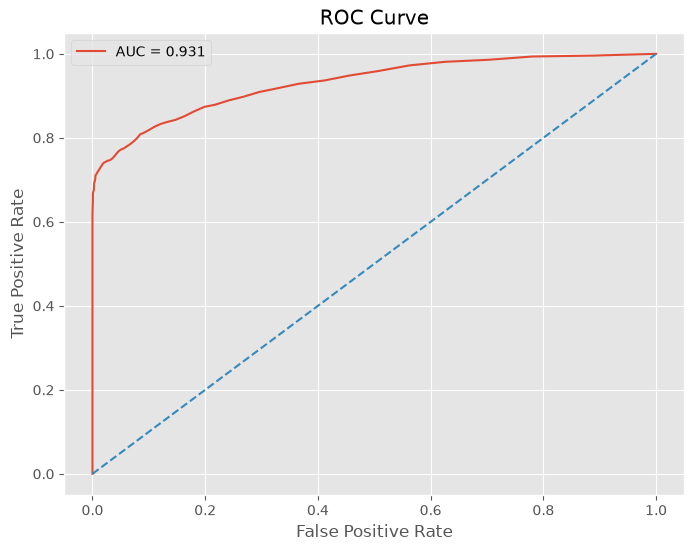

In [64]:
# Plot the ROC Curve for the Random Forest model

rf_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

auc_score = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## 10. Model Saving

In [65]:
# Save the trained Random Forest model

import joblib

joblib.dump(rf, "../models/random_forest_model.pkl")

print("Model saved successfully.")

Model saved successfully.


## 11. Conclusion

This project developed an end-to-end machine learning pipeline for predicting loan default risk using financial and demographic information.

The workflow included:
- Data cleaning
- Exploratory Data Analysis
- Data preprocessing
- Model training
- Performance evaluation

Three classification algorithms were evaluated:
- Logistic Regression
- Decision Tree
- Random Forest

Among them, the Random Forest Classifier achieved the best predictive performance, making it the most suitable model for this dataset. Feature importance analysis and the ROC curve further demonstrated the model's ability to distinguish between low-risk and high-risk loan applicants.